In [1]:
import scanpy as sc
import muon as mu
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
import seaborn as sns
import matplotlib.pyplot as plt

/ihome/ylee/yiz133/.local/lib/python3.11/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
/ihome/ylee/yiz133/.conda/envs/TCR_custom/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-03-10 10:47:24.921042: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-10 10:47:24.921271: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors fro

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Set random seed for reproducibility
SEED = 42
np.random.seed(SEED)
import random
random.seed(SEED)

In [86]:
%%capture
path_count = '/ix1/ylee/Yifan_Zhang/CellRanger_tests/E5S/outs/'
path = path_count


In [87]:
mdata = mu.read_10x_h5(
    path+'filtered_feature_bc_matrix.h5', 
)

# for cellranger count outputs 
mdata_raw = mu.read_10x_h5(
    path+'raw_feature_bc_matrix.h5', 
)

In [88]:
mdata_raw.var_names_make_unique()
mdata.var_names_make_unique()
mdata

MuData object with n_obs × n_vars = 5598 × 33888
  var:	'gene_ids', 'feature_types', 'genome', 'pattern', 'read', 'sequence'
  2 modalities
    rna:	5598 x 33696
      var:	'gene_ids', 'feature_types', 'genome', 'pattern', 'read', 'sequence'
    prot:	5598 x 192
      var:	'gene_ids', 'feature_types', 'genome', 'pattern', 'read', 'sequence'

In [89]:
mdata_raw

MuData object with n_obs × n_vars = 1146827 × 33888
  var:	'gene_ids', 'feature_types', 'genome', 'pattern', 'read', 'sequence'
  2 modalities
    rna:	1146827 x 33696
      var:	'gene_ids', 'feature_types', 'genome', 'pattern', 'read', 'sequence'
    prot:	1146827 x 192
      var:	'gene_ids', 'feature_types', 'genome', 'pattern', 'read', 'sequence'

In [90]:
# filtered_prot = mdata_raw['prot'][:, mdata_raw['prot'].var_names.str.startswith('sbc')]
# mdata_raw.mod['prot'] = filtered_prot
# filtered_prot = mdata['prot'][:, mdata['prot'].var_names.str.startswith('sbc')]
# mdata.mod['prot'] = filtered_prot

In [91]:
sbc_rna = mdata['rna'][:, mdata['rna'].var_names.str.startswith('Sgbc')]
sbc_rna.var_names

Index([], dtype='object')

In [92]:
mdata['rna'].var_names

Index(['Xkr4', 'Gm1992', 'Gm19938', 'Gm37381', 'Rp1', 'Sox17', 'Gm37587',
       'Gm37323', 'Mrpl15', 'A930006A01Rik',
       ...
       'Gm16367', 'ENSMUSG00000094172', 'ENSMUSG00000094887',
       'ENSMUSG00000091585', 'ENSMUSG00000095763', 'ENSMUSG00000095523',
       'ENSMUSG00000095475', 'ENSMUSG00000094855', 'ENSMUSG00000095019',
       'ENSMUSG00000095041'],
      dtype='object', length=33696)

In [93]:
mdata_raw['prot'].var_names

Index(['sbc1', 'sbc2', 'sbc3', 'sbc4', 'sbc5', 'sbc6', 'sbc7', 'sbc8', 'sbc9',
       'sbc10',
       ...
       'sbc183', 'sbc184', 'sbc185', 'sbc186', 'sbc187', 'sbc188', 'sbc189',
       'sbc190', 'sbc191', 'sbc192'],
      dtype='object', length=192)

In [94]:
from muon import prot as pt

In [95]:
prot_DF = mdata['prot'].to_df()
isV12 = False
isFirstHalf = False

if isV12:
    if isFirstHalf:
        rows = [f'sbc{i}' for i in range(1,49)]
        cols = [f'sbc{i}' for i in range(96,144)]
    else:
        rows = [f'sbc{i}' for i in range(48, 96)]
        cols = [f'sbc{i}' for i in range(144, 192)]
else:
    rows = [f'sbc{i}' for i in range(1, 97)]
    cols = [f'sbc{i}' for i in range(97,192)]

cols_to_keep = [c for c in prot_DF.columns if c in rows or c in cols]
prot_DF_filtered = prot_DF[cols_to_keep]
prot_DF_filtered.head()


,sbc1,sbc2,sbc3,sbc4,sbc5,sbc6,sbc7,sbc8,sbc9,sbc10,...,sbc182,sbc183,sbc184,sbc185,sbc186,sbc187,sbc188,sbc189,sbc190,sbc191
AAACCAAAGTTACGAT-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCCTGTTGCTAAC-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCCTGTTTAGGTC-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACGAATCACTCAGA-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACGAATCGCATCAA-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [96]:
BC_by_cell = prot_DF_filtered.where(prot_DF_filtered <= 1, 1)
BC_total = BC_by_cell.sum(axis = 0)

,sbc1,sbc2,sbc3,sbc4,sbc5,sbc6,sbc7,sbc8,sbc9,sbc10,...,sbc182,sbc183,sbc184,sbc185,sbc186,sbc187,sbc188,sbc189,sbc190,sbc191
AAACCAAAGTTACGAT-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCCTGTTGCTAAC-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCCTGTTTAGGTC-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACGAATCACTCAGA-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACGAATCGCATCAA-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TGTGTTAGTGGGTCAG-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TGTGTTGAGAATCAGA-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TGTGTTGAGGCAATCC-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TGTGTTGAGTACGCCG-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [151]:
new_order = []
for i in range(8):  # 16 pairs of 12 = 192 indices
    start_a = 0 + i * 12
    start_b = 96 + i * 12
    new_order += list(range(start_a, start_a + 12)) + list(range(start_b, start_b + 12))

BC_total_reordered = BC_total.iloc[new_order[:-1]].to_list()

# BC_total = BC_total_reoredered

In [154]:
BC_total['sbc166']

840.0

Text(0, 0.5, 'Frequency')

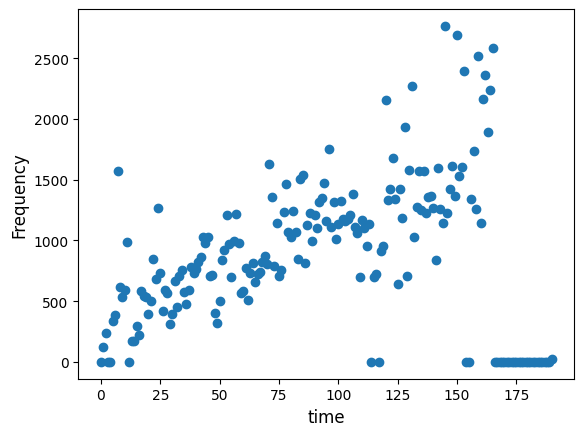

In [155]:
plt.scatter(np.arange(len(BC_total_reordered)), np.array(BC_total_reordered))
plt.xlabel('time', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
# plt.ylim([0, 100])

Text(0, 0.5, 'Frequency')

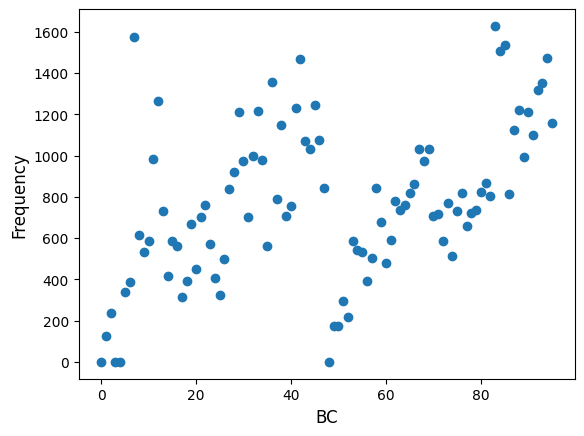

In [143]:
first_half = BC_total.iloc[list(range(0,48)) + list(range(96,144))]
plt.scatter(np.arange(0,len(first_half)), first_half)
plt.xlabel('BC', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

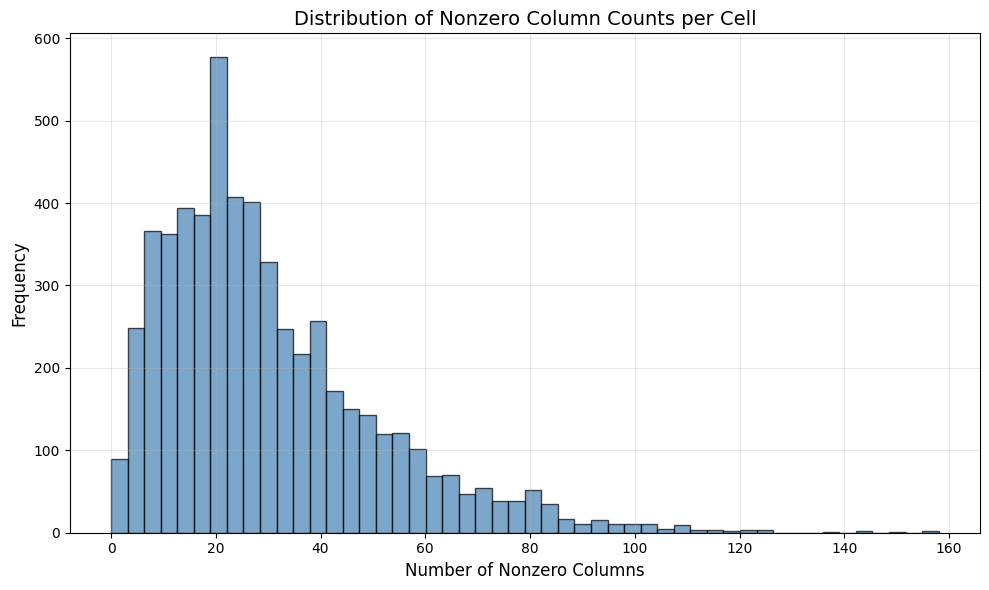

Summary Statistics for Nonzero Column Counts:
Mean: 30.12
Median: 25.00
Std Dev: 20.82
Min: 0
Max: 158


In [101]:
# Count nonzero columns per row
nonzero_col_counts = (prot_DF_filtered != 0).sum(axis=1)

# Plot distribution
plt.figure(figsize=(10, 6), dpi=100)
plt.hist(nonzero_col_counts, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
plt.xlabel('Number of Nonzero Columns', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Nonzero Column Counts per Cell', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print summary statistics
print(f"Summary Statistics for Nonzero Column Counts:")
print(f"Mean: {nonzero_col_counts.mean():.2f}")
print(f"Median: {nonzero_col_counts.median():.2f}")
print(f"Std Dev: {nonzero_col_counts.std():.2f}")
print(f"Min: {nonzero_col_counts.min()}")
print(f"Max: {nonzero_col_counts.max()}")

In [102]:
prot_DF_filtered.to_csv('raw_BCs.csv')

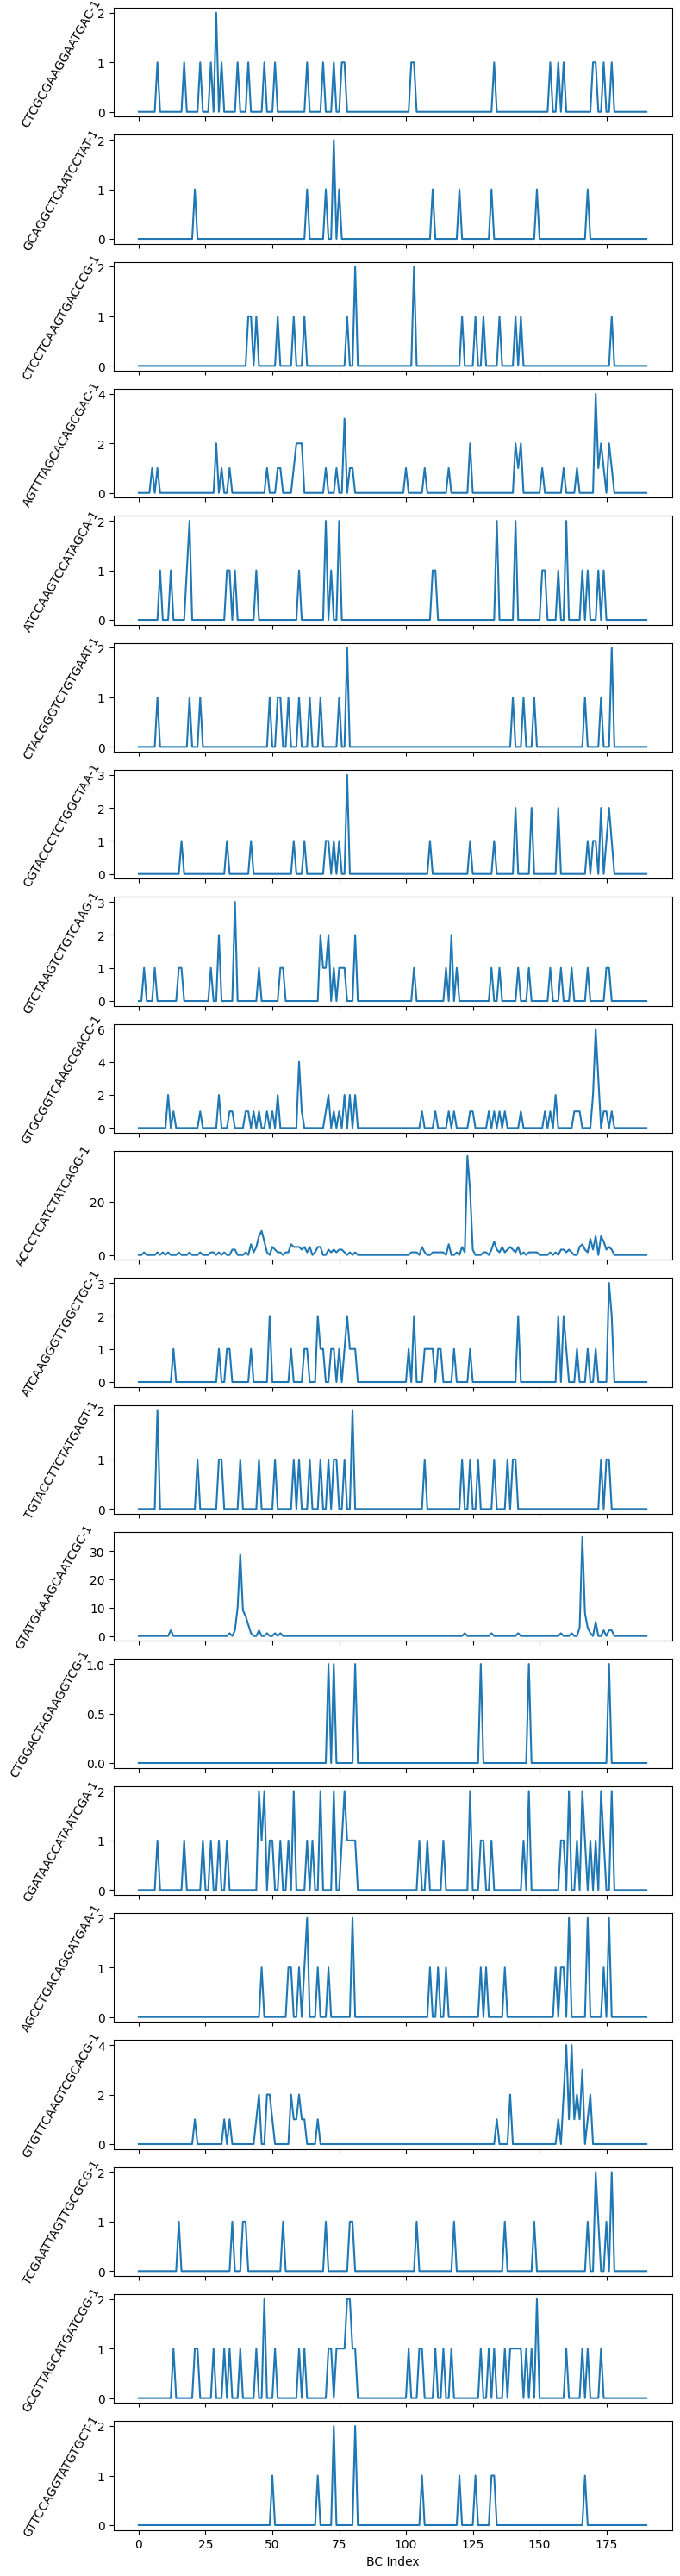

In [103]:
import matplotlib.pyplot as plt

k = 20 # number of rows to sample
sampled = prot_DF_filtered.sample(n=k, replace=False)

fig, axes = plt.subplots(
    nrows=k,
    ncols=1,
    figsize=(8, 1.5 * k),  # reduced height per subplot
    sharex=True
)

# If k == 1, axes is not a list
if k == 1:
    axes = [axes]

for ax, (idx, row) in zip(axes, sampled.iterrows()):
    ax.plot(row.values)
    ax.set_ylabel(str(idx), rotation=60, labelpad=30, va="center")

axes[-1].set_xlabel("BC Index")
plt.tight_layout()
plt.savefig('BC.png')
plt.show()


## load BC from gene

In [104]:
adata = sc.read_10x_h5(path+'filtered_feature_bc_matrix.h5', gex_only=False)
adata.var_names_make_unique()
adata.var.loc[adata.var.gene_ids.str.startswith('sgbc'), "feature_types"] = "Spatial Capture"

sbcs = adata.var_names[adata.var_names.str.contains('sbc')]

In [105]:
adata = sc.read_10x_h5(path+'filtered_feature_bc_matrix.h5', gex_only=False)
adata_temp = adata

In [106]:
adata_temp.var

,gene_ids,feature_types,genome,pattern,read,sequence
Xkr4,ENSMUSG00000051951,Gene Expression,GRCm39,,,
Gm1992,ENSMUSG00000089699,Gene Expression,GRCm39,,,
Gm19938,ENSMUSG00000102331,Gene Expression,GRCm39,,,
Gm37381,ENSMUSG00000102343,Gene Expression,GRCm39,,,
Rp1,ENSMUSG00000025900,Gene Expression,GRCm39,,,
...,...,...,...,...,...,...
sbc188,sgbc-tsb-v2-188,Antibody Capture,,5P(BC),R2,TATCGTCTCATCAGC
sbc189,sgbc-tsb-v2-189,Antibody Capture,,5P(BC),R2,GCACTAGTACGCCGC
sbc190,sgbc-tsb-v2-190,Antibody Capture,,5P(BC),R2,AGGGCGCCCTAATAA
sbc191,sgbc-tsb-v2-191,Antibody Capture,,5P(BC),R2,TTACCACACGAACGA


In [107]:
rows = [f'sbc{i}' for i in range(48, 96)]
cols = [f'sbc{i}' for i in range(144, 192)]
df = pd.DataFrame(index=rows, columns=cols)
for r in rows:
    for c in cols:
        df.loc[r, c] = f'{r}-{c}'

x = []
y = []

### Search with only 2 BCs

In [108]:
df_X = adata.to_df()[df.index]
nonzero_counts = (df_X != 0).sum(axis=1)
xBC_counts = nonzero_counts.clip(upper=2).tolist()

df_Y = adata.to_df()[df.columns]
nonzero_counts = (df_Y != 0).sum(axis=1)
yBC_counts = nonzero_counts.clip(upper=2).tolist()

error_thres = 10
singleBC_idx = []
print_error_X = 0
print_error_Y = 0
oligo_error_X = 0
oligo_error_Y = 0

for i in range(len(xBC_counts)):
    if xBC_counts[i] == 2:
        nz_idx = np.where(df_X.iloc[i,:].to_numpy() != 0)[0]
        if nz_idx.max() - nz_idx.min() < error_thres:
            print_error_X += 1
        else:
            oligo_error_X += 1
        
    if yBC_counts[i] == 2:
        nz_idy = np.where(df_Y.iloc[i,:].to_numpy() != 0)[0]
        if nz_idy.max() - nz_idy.min() < error_thres:
            print_error_Y += 1
        else:
            oligo_error_Y += 1
    
    if xBC_counts[i] == 1 and yBC_counts[i] == 1:
        singleBC_idx.append(i)
        
count_nonzero = sum(x != 0 for x in singleBC_idx)
print(str(count_nonzero) + 'in' + str(len(xBC_counts))) 
print('adjacent error X ' + str(print_error_X))
print(oligo_error_X)
print('adjacent error Y ' + str(print_error_Y))
print(oligo_error_Y)

47in5598
adjacent error X 292
4999
adjacent error Y 335
4861


In [109]:
top10 = df_X.replace(0, np.nan)

## Select top

In [110]:
df_adata = adata.to_df()[df.index]

topK = 20

top10 = df_adata.replace(0, np.nan).apply(lambda row: row.nlargest(topK).dropna().index.tolist(), axis=1)

x = [
    np.random.choice(choices) if len(choices) >= 1 else None
    for choices in top10
]

df_adata = adata.to_df()[df.columns]
top10 = df_adata.replace(0, np.nan).apply(lambda row: row.nlargest(topK).dropna().index.tolist(), axis=1)

y = [
    np.random.choice(choices) if len(choices) >= 1 else None
    for choices in top10
]

len(x), len(y)

(5598, 5598)

In [111]:
xy_raw = pd.DataFrame({'x': x, 'y': y})
xy_raw

,x,y
0,sbc61,sbc177
1,sbc78,sbc163
2,sbc76,sbc175
3,sbc79,sbc169
4,sbc81,sbc169
...,...,...
5593,sbc80,sbc171
5594,sbc61,sbc152
5595,sbc55,sbc150
5596,sbc64,sbc174


In [112]:
import matplotlib.pyplot as plt

# Categorize each row
def categorize(row):
    x_missing = pd.isna(row['x'])
    y_missing = pd.isna(row['y'])
    if not x_missing and not y_missing:
        return "both"
    elif x_missing and not y_missing:
        return "only y"
    elif not x_missing and y_missing:
        return "only x"
    else:
        return "neither"

category_counts = xy_raw.apply(categorize, axis=1).value_counts().reindex(["only x", "only y", "both", "neither"], fill_value=0)

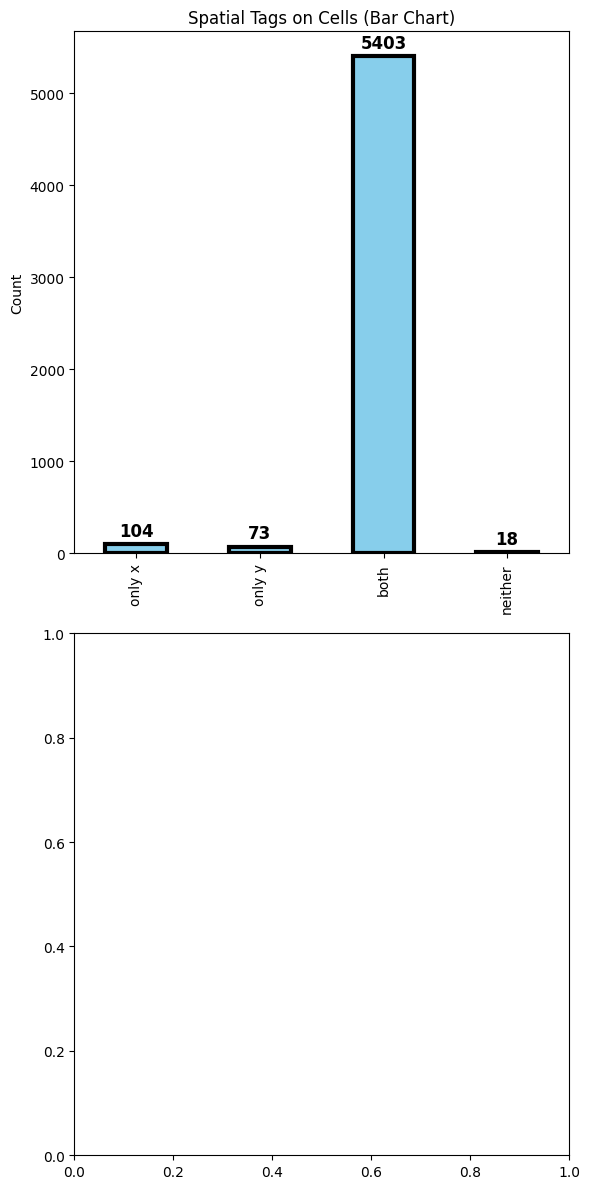

In [113]:
fig, axes = plt.subplots(2, 1, figsize=(6, 12), dpi=100)

# Bar chart (original)
bars = category_counts.plot(kind="bar", linewidth=3, edgecolor='black', ax=axes[0], color='skyblue')
axes[0].set_ylabel("Count")
axes[0].set_title("Spatial Tags on Cells (Bar Chart)")

# Add cell number (count) on each bar
for p in axes[0].patches:
    count = int(p.get_height())
    axes[0].annotate(str(count), 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom',
                    fontsize=12, fontweight='bold', xytext=(0, 3), textcoords='offset points')

plt.tight_layout()
plt.show()

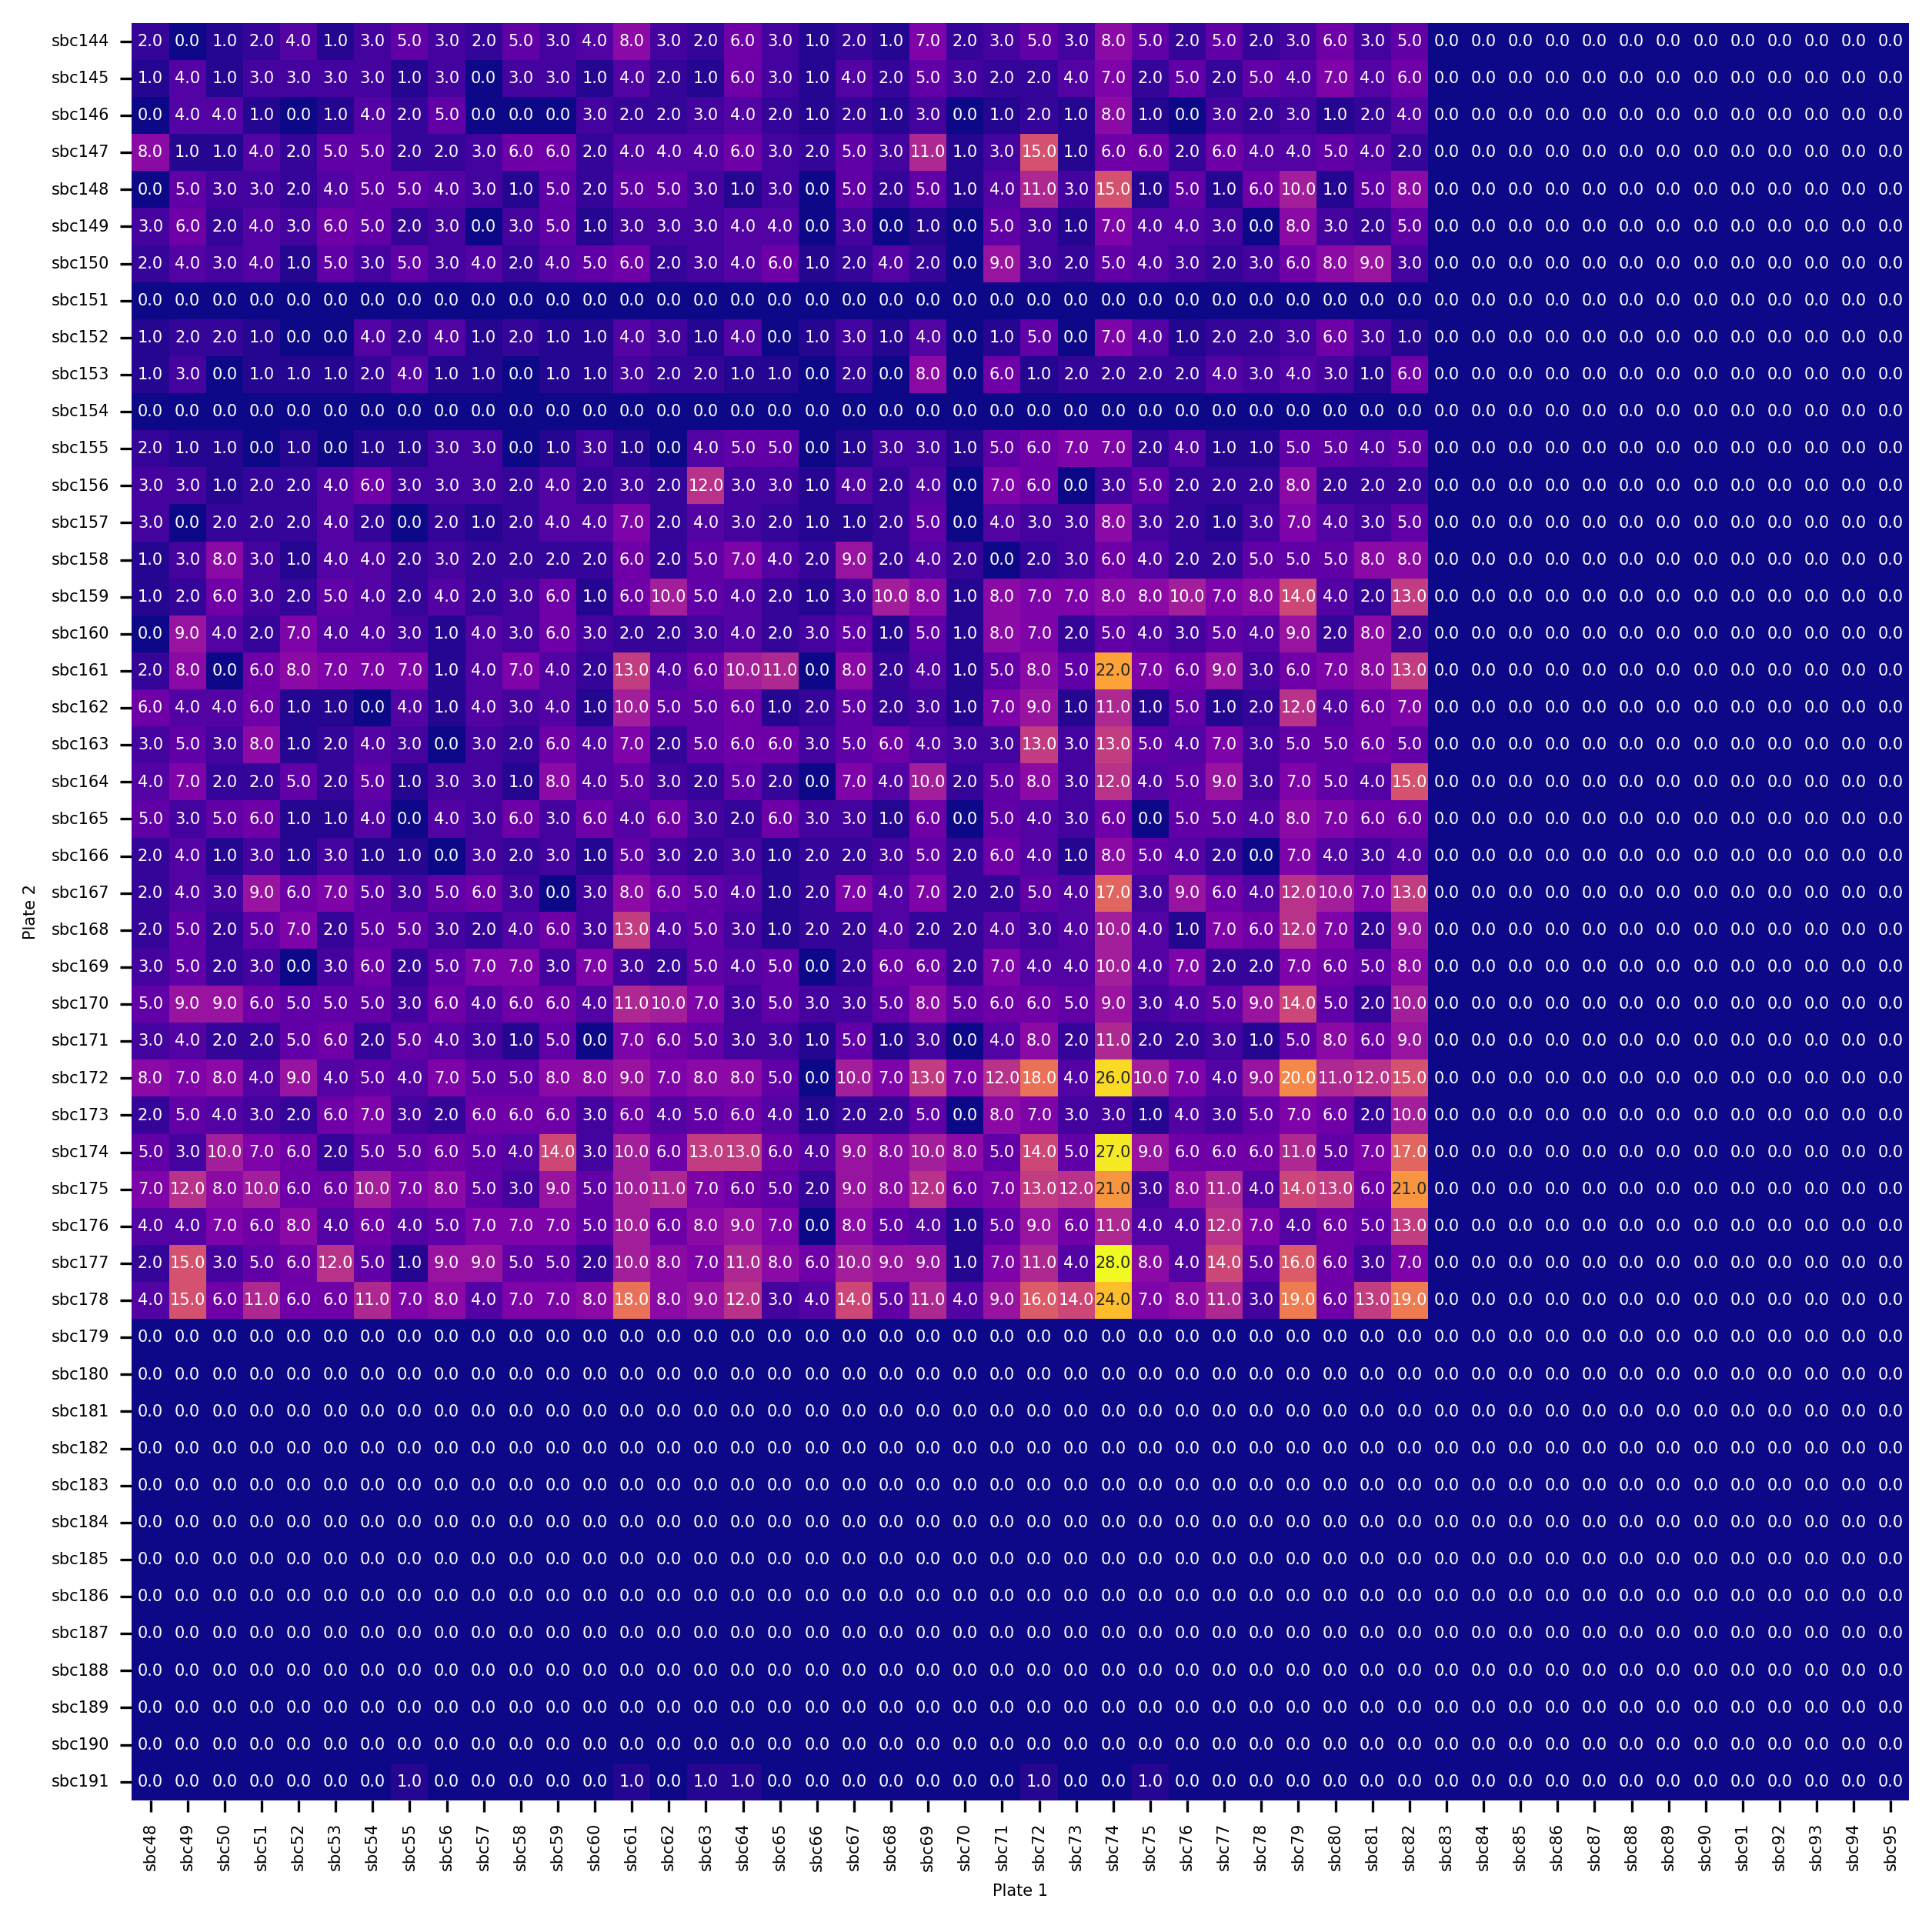

In [114]:
heatmap_data = xy_raw.value_counts().reset_index(
    name='count').pivot(index='x', columns='y', values='count').fillna(0)
heatmap_data = heatmap_data.reindex(df.index).T.reindex(df.columns).T.fillna(0).T

plt.figure(figsize=(10, 10), dpi=300)
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.1f',
    cmap='plasma',
    square=True,
    cbar=False,
    annot_kws={"size":5},
    xticklabels=1,
    yticklabels=1
)
plt.xticks(fontsize=5)
plt.yticks(fontsize=5)
plt.xlabel('Plate 1', fontsize=5)
plt.ylabel('Plate 2', fontsize=5)
plt.savefig('/tmp/heatmap_raw.png', dpi=300)
plt.show()